# Touch Log — Exploratory Data Analysis
**Human Touch Archive · School of Tomorrow's AI**  
*Autoethnographic dataset · May 21 – Jun 2, 2026*

This notebook performs a full EDA on the Form A touch log collected via Google Forms.  
Data is read directly from the published CSV — no local files needed.

---
### Structure
1. Setup & data loading  
2. Data cleaning & feature engineering  
3. Overview stats  
4. Distribution analyses  
5. Timeline & circadian rhythm  
6. Cross-tabulations  
7. Form A vs Inferred events  
8. Highlights & observations


In [1]:
# ── 1. SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Brand palette — School of Tomorrow's AI
DEEP_PURPLE  = '#22113E'
GRAY_GREEN   = '#CAD8D8'
PINK         = '#EA7DFF'
TURQUOISE    = '#08F2DB'
WHITE        = '#FFFFFF'

# Person colors
PERSON_COLORS = {
    'Uma':                         PINK,
    'Partner':                     TURQUOISE,
    'Friend':                      GRAY_GREEN,
    'Family':                      '#A0B4B4',
    'Professional / service interaction': '#6A7A7A',
}

def brand_fig(figsize=(12, 5)):
    """Return a figure with deep purple background."""
    fig = plt.figure(figsize=figsize, facecolor=DEEP_PURPLE)
    return fig

def style_ax(ax, title=None):
    """Apply brand styling to an axis."""
    ax.set_facecolor(DEEP_PURPLE)
    for spine in ax.spines.values():
        spine.set_color('#3a2a5e')
    ax.tick_params(colors=GRAY_GREEN, labelsize=9)
    ax.xaxis.label.set_color(GRAY_GREEN)
    ax.yaxis.label.set_color(GRAY_GREEN)
    if title:
        ax.set_title(title, color=WHITE, fontsize=11, fontweight='normal', pad=10)
    ax.grid(axis='y', color='#3a2a5e', linewidth=0.5, linestyle='--')
    ax.set_axisbelow(True)
    return ax

print("✓ Setup complete — brand palette loaded")


✓ Setup complete — brand palette loaded


## 1 · Data Loading

In [2]:
# ── 2. LOAD DATA
CSV_URL = (
    "https://docs.google.com/spreadsheets/d/e/"
    "2PACX-1vSJ2_L5hKxn8GjWzoNhpr0y2Dw14yRye52tePIUut46C44L0HTFvHHKk2xgDeAyqly_cfpyqe3jrCmu"
    "/pub?gid=714232102&single=true&output=csv"
)

raw = pd.read_csv(CSV_URL)
print(f"Shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head(3)


Shape: (192, 14)
Columns: ['Timestamp', '1. When did it happen?', '2. Who?', '3. Type of contact', '4. Intention', '5. Duration', '7. Optional note (Add a short note if something about this touch felt meaningful, strange, automatic, caring, uncomfortable, tender, or difficult to classify.)', '6. Location', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']


,Timestamp,1. When did it happen?,2. Who?,3. Type of contact,4. Intention,5. Duration,"7. Optional note (Add a short note if something about this touch felt meaningful, strange, automatic, caring, uncomfortable, tender, or difficult to classify.)",6. Location,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,5/21/2026 12:59:23,Now,Uma,Touch - Standard,Comfort/Calming,Brief — 2–10 seconds,NaN,Home / Atelier,NaN,NaN,NaN,NaN,NaN,NaN
1,5/21/2026 14:04:26,Now,Uma,Touch - Functional,"Care, Functional / practical",Brief — 2–10 seconds,NaN,Home / Atelier,NaN,NaN,NaN,NaN,NaN,NaN
2,5/21/2026 15:28:03,30 minutes ago,Uma,Hug - Holding / carrying,"Care, Affection",Extended care / holding — more than 10 minutes,NaN,Home / Atelier,NaN,NaN,NaN,NaN,NaN,NaN


## 2 · Cleaning & Feature Engineering

In [3]:
# ── 3. CLEAN & ENGINEER FEATURES

# Rename columns to clean slugs
raw.columns = raw.columns.str.strip()
col_map = {
    raw.columns[0]: 'timestamp',
    raw.columns[1]: 'when_happened',
    raw.columns[2]: 'person',
    raw.columns[3]: 'contact_type',
    raw.columns[4]: 'intention',
    raw.columns[5]: 'duration',
    raw.columns[6]: 'note',
    raw.columns[7]: 'location',
}
# Handle extra columns (inferred metadata) gracefully
if len(raw.columns) > 8:
    for i, c in enumerate(raw.columns[8:], start=8):
        col_map[c] = f'meta_{i}'

df = raw.rename(columns=col_map).copy()

# Parse timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Drop completely empty rows
df = df.dropna(subset=['timestamp', 'person', 'contact_type'])

# Flag inferred events
df['is_inferred'] = df['when_happened'].astype(str).str.strip().str.lower() == 'inferred'

# Date / time features
df['date']       = df['timestamp'].dt.date
df['hour']       = df['timestamp'].dt.hour
df['day_of_week']= df['timestamp'].dt.day_name()
df['week_day_n'] = df['timestamp'].dt.dayofweek   # 0=Mon

# Clean person — strip whitespace
df['person'] = df['person'].str.strip()

# Simplify contact_type family
df['contact_family'] = df['contact_type'].str.split(' - ').str[0].str.strip()  # Hug / Touch

# Duration ordinal mapping
DUR_ORDER = {
    'Very brief — less than 2 seconds': 1,
    'Brief — 2–10 seconds':             2,
    'Medium — 10–30 seconds':           3,
    "Long — 30 seconds–2 minutes":      4,
    'Very long — 2–10 minutes':         5,
    'Extended care / holding — more than 10 minutes': 6,
    "I'm not sure":                     0,
}
df['duration_ord'] = df['duration'].map(DUR_ORDER).fillna(0).astype(int)

# Split multi-intention rows into list column
df['intention_list'] = df['intention'].fillna('').str.split(', ')

# Separate Form A (real-time) from Inferred
formA    = df[~df['is_inferred']].copy()
inferred = df[df['is_inferred']].copy()

print(f"Total rows:  {len(df)}")
print(f"Form A:      {len(formA)}")
print(f"Inferred:    {len(inferred)}")
print(f"Date range:  {df['date'].min()} → {df['date'].max()}")
df.dtypes


Total rows:  192
Form A:      143
Inferred:    49
Date range:  2026-05-21 → 2026-06-02


timestamp         datetime64[ns]
when_happened             object
person                    object
contact_type              object
intention                 object
duration                  object
note                      object
location                  object
meta_8                    object
meta_9                    object
meta_10                   object
meta_11                   object
meta_12                   object
meta_13                   object
is_inferred                 bool
date                      object
hour                       int32
day_of_week               object
week_day_n                 int32
contact_family            object
duration_ord               int64
intention_list            object
dtype: object

## 3 · Overview Stats

In [4]:
# ── 4. OVERVIEW STATS (Form A only)
days = formA['date'].nunique()
total = len(formA)

print("=" * 45)
print(f"  TOUCH LOG — FORM A OVERVIEW")
print("=" * 45)
print(f"  Total events logged (real-time): {total}")
print(f"  Days covered:                    {days}")
print(f"  Average events / day:            {total/days:.1f}")
print(f"  Most active day:                 {formA.groupby('date').size().idxmax()} "
      f"({formA.groupby('date').size().max()} events)")
print(f"  Least active day:                {formA.groupby('date').size().idxmin()} "
      f"({formA.groupby('date').size().min()} events)")
print()
print("  Events by person:")
for p, c in formA['person'].value_counts().items():
    bar = '█' * int(c / total * 40)
    print(f"    {p:<35} {c:>3}  {bar}")
print()
print("  Location split:")
for l, c in formA['location'].value_counts().items():
    print(f"    {l:<35} {c:>3}  ({c/total*100:.0f}%)")


  TOUCH LOG — FORM A OVERVIEW
  Total events logged (real-time): 143
  Days covered:                    13
  Average events / day:            11.0
  Most active day:                 2026-05-25 (21 events)
  Least active day:                2026-05-21 (5 events)

  Events by person:
    Uma                                  66  ██████████████████
    Partner                              59  ████████████████
    Friend                               10  ██
    Family                                6  █
    Professional / service interaction    2  

  Location split:
    Home / Atelier                      112  (78%)
    Outside / World                      31  (22%)


## 4 · Distribution Analyses

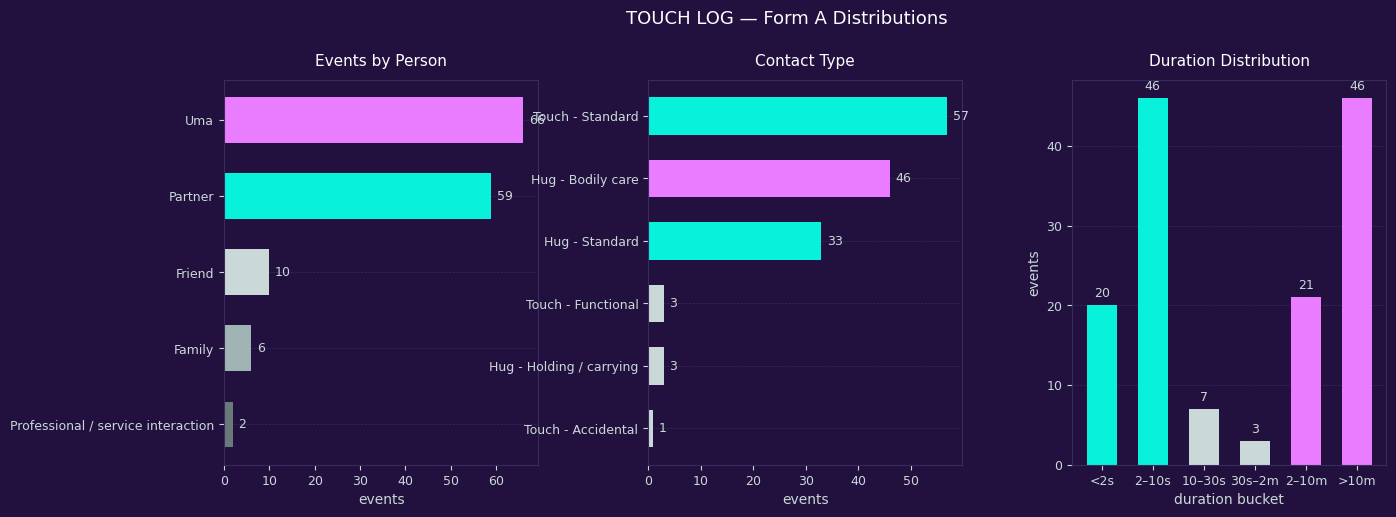

Saved → eda_01_distributions.png


In [5]:
# ── 5a. PERSON / CONTACT TYPE / DURATION — 3-panel figure

fig = brand_fig(figsize=(15, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Person ---
ax1 = fig.add_subplot(gs[0])
style_ax(ax1, 'Events by Person')
pc = formA['person'].value_counts()
colors_p = [PERSON_COLORS.get(p, GRAY_GREEN) for p in pc.index]
bars = ax1.barh(pc.index, pc.values, color=colors_p, height=0.6)
ax1.bar_label(bars, fmt='%d', color=GRAY_GREEN, fontsize=9, padding=4)
ax1.invert_yaxis()
ax1.set_xlabel('events')

# --- Contact type ---
ax2 = fig.add_subplot(gs[1])
style_ax(ax2, 'Contact Type')
ct = formA['contact_type'].value_counts()
ct_colors = [PINK if 'Bodily' in t else TURQUOISE if 'Standard' in t else GRAY_GREEN for t in ct.index]
bars2 = ax2.barh(ct.index, ct.values, color=ct_colors, height=0.6)
ax2.bar_label(bars2, fmt='%d', color=GRAY_GREEN, fontsize=9, padding=4)
ax2.invert_yaxis()
ax2.set_xlabel('events')

# --- Duration ---
ax3 = fig.add_subplot(gs[2])
style_ax(ax3, 'Duration Distribution')
dur_labels_short = {
    'Very brief — less than 2 seconds':   '<2s',
    'Brief — 2–10 seconds':               '2–10s',
    'Medium — 10–30 seconds':             '10–30s',
    "Long — 30 seconds–2 minutes":        '30s–2m',
    'Very long — 2–10 minutes':           '2–10m',
    'Extended care / holding — more than 10 minutes': '>10m',
    "I'm not sure":                       '?',
}
dur_counts = (formA['duration']
              .map(dur_labels_short)
              .value_counts()
              .reindex(['<2s','2–10s','10–30s','30s–2m','2–10m','>10m','?'])
              .dropna())
dur_col = [TURQUOISE if v in ['<2s','2–10s'] else PINK if v in ['>10m','2–10m'] else GRAY_GREEN
           for v in dur_counts.index]
bars3 = ax3.bar(dur_counts.index, dur_counts.values, color=dur_col, width=0.6)
ax3.bar_label(bars3, fmt='%d', color=GRAY_GREEN, fontsize=9, padding=4)
ax3.set_xlabel('duration bucket')
ax3.set_ylabel('events')

fig.suptitle('TOUCH LOG — Form A Distributions', color=WHITE,
             fontsize=13, fontweight='normal', y=1.02)
plt.tight_layout()
plt.savefig('eda_01_distributions.png', dpi=150, bbox_inches='tight',
            facecolor=DEEP_PURPLE)
plt.show()
print("Saved → eda_01_distributions.png")


### Observations — Distributions

The person breakdown confirms what was expected: Uma and Partner together account for 86% of all
logged events, with Friend, Family, and Professional contacts as a distant tail. More interesting
than the dominance itself is what it implies about the dataset's scope — this is not a log of
social touch; it is primarily a log of domestic and intimate touch.

The contact type panel shows that Touch - Standard and Hug - Bodily care together cover nearly
75% of all events. The gap between these two categories and everything else (Hug - Standard,
Functional, Accidental) suggests that the vocabulary of everyday touch is narrower than expected.

The duration panel is the most structurally revealing of the three. The distribution is strongly
bimodal: the two dominant buckets are Brief (2–10s) with 46 events, and Extended (>10 min) with
46 events — tied at the extremes, with almost nothing in between. Medium and Long durations
(10s–2 min) account for only 10 events combined. This is not a bell curve. **Touch either happens
as a quick social gesture or as a sustained bodily condition. There is very little in the middle.**

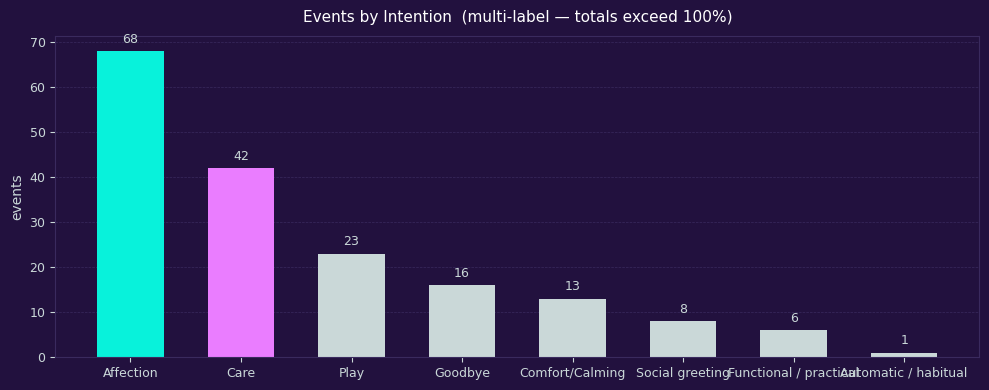

Affection + Play co-occur: 18 events
  → {'Partner': 16, 'Uma': 2}


In [6]:
# ── 5b. INTENTION breakdown (exploded — one row per intention)

from collections import Counter

all_intentions = [i.strip() for sublist in formA['intention_list'] for i in sublist if i.strip()]
intent_counts = pd.Series(Counter(all_intentions)).sort_values(ascending=False)

fig, ax = brand_fig(figsize=(10, 4)), None
ax = fig.add_subplot(111)
style_ax(ax, 'Events by Intention  (multi-label — totals exceed 100%)')
intent_colors = [PINK if i == 'Care' else TURQUOISE if i == 'Affection'
                 else GRAY_GREEN for i in intent_counts.index]
bars = ax.bar(intent_counts.index, intent_counts.values, color=intent_colors, width=0.6)
ax.bar_label(bars, fmt='%d', color=GRAY_GREEN, fontsize=9, padding=4)
ax.set_ylabel('events')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('eda_02_intentions.png', dpi=150, bbox_inches='tight', facecolor=DEEP_PURPLE)
plt.show()

# Co-occurrence note
play_affection = formA[formA['intention'].str.contains('Play', na=False) &
                       formA['intention'].str.contains('Affection', na=False)]
print(f"Affection + Play co-occur: {len(play_affection)} events")
print(f"  → {play_affection['person'].value_counts().to_dict()}")


### Observations — Intentions

Affection leads with 68 occurrences, followed by Care (42) and Play (23). Because the form
allowed multiple intentions per event, totals exceed 100% — meaning many touch events carry
more than one simultaneous meaning, which is itself a finding.

The position of Play in third place, above Goodbye and Comfort/Calming, is counterintuitive
for a log framed around care and hugs. It reflects the presence of a baby in the household:
a significant portion of touch is not tender or consoling — it is playful, physical, and
reciprocally initiated. Touch as play is as structurally present as touch as farewell.

Goodbye appears 16 times, almost always brief — a farewell kiss or quick hug at the door.
Comfort/Calming (13 events) and Social greeting (8 events) are relatively rare as primary
intentions, which may reflect genuine frequency or the difficulty of logging in those moments.
Functional and Automatic/habitual together account for only 7 events — suggesting that
instrumental or unconscious touch is either genuinely rare or systematically under-noticed
and therefore under-logged.

## 5 · Timeline & Circadian Rhythm

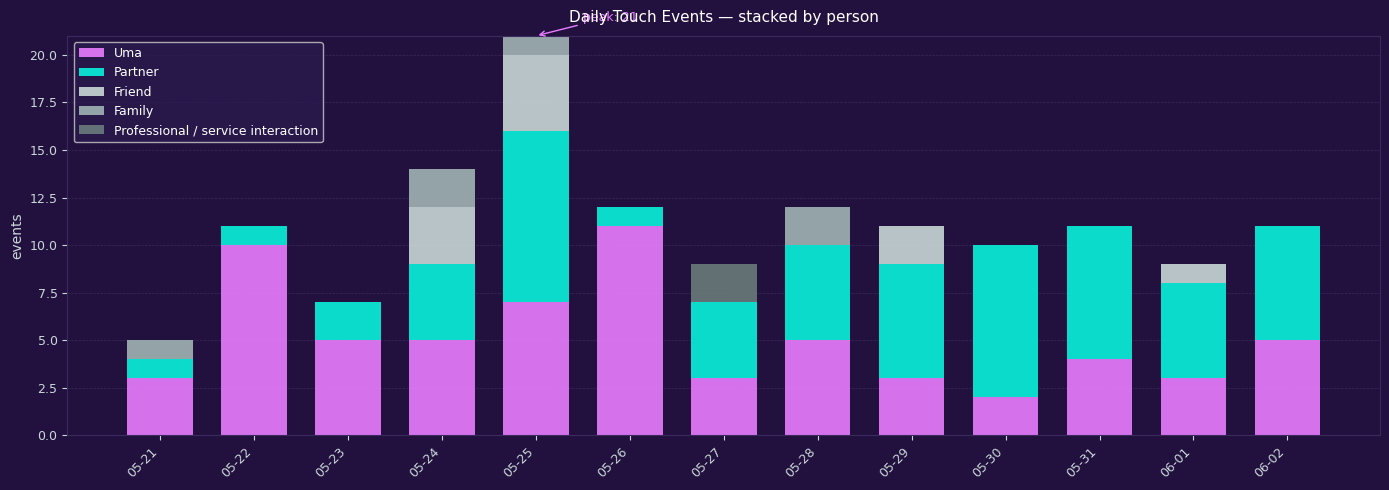

In [7]:
# ── 6a. DAILY TIMELINE — stacked by person

daily_person = (formA.groupby(['date','person'])
                .size().unstack(fill_value=0)
                .reindex(columns=list(PERSON_COLORS.keys()), fill_value=0))

fig, ax = brand_fig(figsize=(14, 5)), None
ax = fig.add_subplot(111, facecolor=DEEP_PURPLE)
style_ax(ax, 'Daily Touch Events — stacked by person')

bottom = np.zeros(len(daily_person))
for person in daily_person.columns:
    vals = daily_person[person].values
    color = PERSON_COLORS.get(person, GRAY_GREEN)
    ax.bar(range(len(daily_person)), vals, bottom=bottom,
           color=color, label=person, width=0.7, alpha=0.9)
    bottom += vals

ax.set_xticks(range(len(daily_person)))
ax.set_xticklabels([str(d)[5:] for d in daily_person.index],
                   rotation=45, ha='right', fontsize=9, color=GRAY_GREEN)
ax.set_ylabel('events')
ax.legend(facecolor='#2a1a4e', labelcolor=WHITE, framealpha=0.8,
          fontsize=9, loc='upper left')

# annotate peak
peak_idx = int(np.argmax(bottom))
ax.annotate(f"peak: {int(max(bottom))}",
            xy=(peak_idx, max(bottom)),
            xytext=(peak_idx + 0.5, max(bottom) + 0.8),
            color=PINK, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=PINK, lw=1))

plt.tight_layout()
plt.savefig('eda_03_daily_timeline.png', dpi=150, bbox_inches='tight', facecolor=DEEP_PURPLE)
plt.show()


### Observations — Daily Timeline

The stacked bar chart shows a relatively stable daily rhythm between 9 and 12 events per day,
with two notable exceptions. May 25 is the clear peak at 21 events — the first full day outside
the home, combining family visits, friend encounters, and goodbye hugs into a single day. The
composition of that bar is also the most varied, with Friend and Family layers visible above
the Uma/Partner base.

On most domestic days, the bar is almost entirely Uma (pink) and Partner (teal), with no visible
social layers. The grey tones of Friend and Family only appear when there is a social event or
outing. This confirms that the dataset has two structurally different day-types: domestic days
(intimate, repetitive, high Uma presence) and social days (more varied, higher total counts,
more people).

May 27 shows a notably reduced Uma layer compared to surrounding days — worth cross-referencing
with Form B notes for that date to understand whether it reflects a real change in care pattern
or a logging gap.

June 2 is still in progress at the time of export and should be treated as a partial observation.

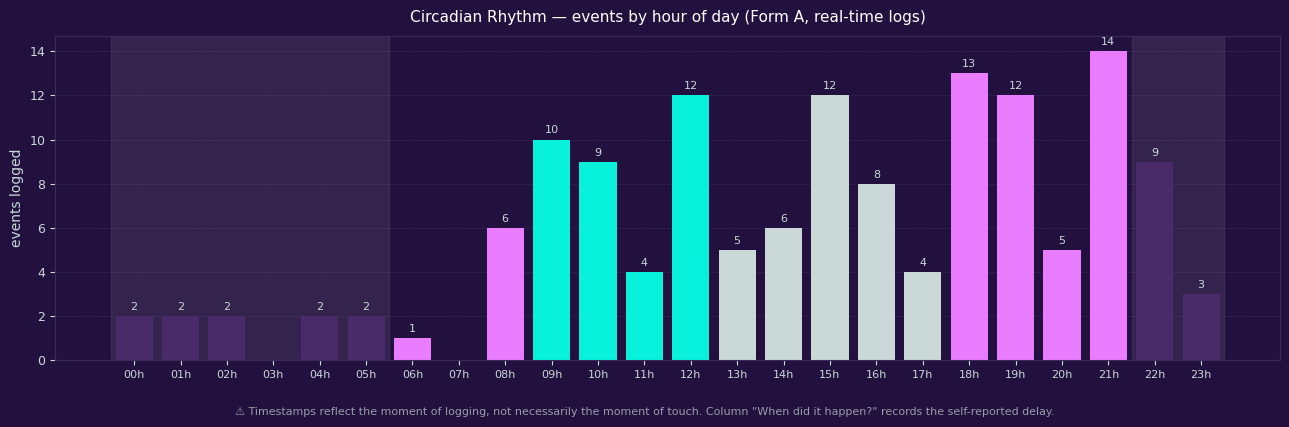

In [8]:
# ── 6b. CIRCADIAN RHYTHM — events by hour of day

fig = brand_fig(figsize=(13, 4))
ax  = fig.add_subplot(111)
style_ax(ax, 'Circadian Rhythm — events by hour of day (Form A, real-time logs)')

hourly = formA.groupby('hour').size().reindex(range(24), fill_value=0)

# Color by time of day
hour_colors = []
for h in range(24):
    if   h < 6:   hour_colors.append('#3a1a5e')   # night
    elif h < 9:   hour_colors.append(PINK)         # early morning
    elif h < 13:  hour_colors.append(TURQUOISE)    # morning
    elif h < 18:  hour_colors.append(GRAY_GREEN)   # afternoon
    elif h < 22:  hour_colors.append(PINK)         # evening
    else:         hour_colors.append('#3a1a5e')    # late night

bars = ax.bar(hourly.index, hourly.values, color=hour_colors, width=0.8)
ax.bar_label(bars, fmt=lambda x: str(int(x)) if x > 0 else '',
             color=GRAY_GREEN, fontsize=8, padding=3)
ax.set_xticks(range(24))
ax.set_xticklabels([f'{h:02d}h' for h in range(24)], fontsize=8)
ax.set_ylabel('events logged')

# Annotate sleep hours
ax.axvspan(-0.5, 5.5, alpha=0.08, color=WHITE, label='night / sleep')
ax.axvspan(21.5, 23.5, alpha=0.08, color=WHITE)

# Note about logging delay
fig.text(0.5, -0.05,
         '⚠ Timestamps reflect the moment of logging, not necessarily the moment of touch. '
         'Column "When did it happen?" records the self-reported delay.',
         ha='center', color=GRAY_GREEN, fontsize=8, alpha=0.7)

plt.tight_layout()
plt.savefig('eda_04_circadian.png', dpi=150, bbox_inches='tight', facecolor=DEEP_PURPLE)
plt.show()


### Observations — Circadian Rhythm

The hourly distribution reveals a clear two-peak structure: a morning cluster between 09h–12h
and an evening cluster between 18h–21h, with a trough in the early afternoon (13h–14h) and
another around 17h. This pattern is consistent with a domestic day structured around a baby's
sleep and feeding schedule rather than a conventional work schedule.

The most unexpected finding is the presence of 2 logged events per hour between 00h and 05h.
These are almost certainly nighttime care events with Uma — logged in real time during waking
moments. This means the dataset partially captures what most self-tracking studies miss entirely:
the nocturnal dimension of parental care touch.

One important methodological caveat: timestamps reflect the moment of logging, not necessarily
the moment of touch. The column "When did it happen?" records the self-reported delay between
event and log entry. Events logged with a delay of 15 minutes or more will appear shifted
forward in the circadian profile. The morning peak may partly reflect events that happened
earlier but were logged once a quieter moment allowed it.

## 6 · Cross-tabulations

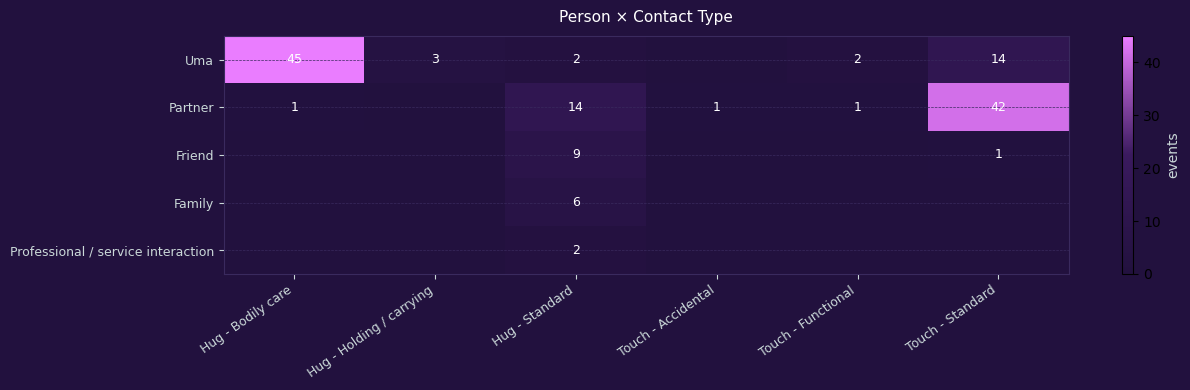

In [9]:
# ── 7a. PERSON × CONTACT TYPE heatmap

import matplotlib.colors as mcolors

ct_pivot = pd.crosstab(formA['person'], formA['contact_type'])
ct_pivot = ct_pivot.loc[ct_pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = brand_fig(figsize=(13, 4)), None
ax = fig.add_subplot(111)
style_ax(ax, 'Person × Contact Type')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'brand', [DEEP_PURPLE, '#3a1a5e', PINK])
im = ax.imshow(ct_pivot.values, aspect='auto', cmap=cmap, vmin=0)

ax.set_xticks(range(len(ct_pivot.columns)))
ax.set_xticklabels(ct_pivot.columns, rotation=35, ha='right',
                   fontsize=9, color=GRAY_GREEN)
ax.set_yticks(range(len(ct_pivot.index)))
ax.set_yticklabels(ct_pivot.index, fontsize=9, color=GRAY_GREEN)

for i in range(len(ct_pivot.index)):
    for j in range(len(ct_pivot.columns)):
        v = ct_pivot.values[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center',
                    color=WHITE, fontsize=9)

plt.colorbar(im, ax=ax, label='events').ax.yaxis.label.set_color(GRAY_GREEN)
plt.tight_layout()
plt.savefig('eda_05_person_x_type.png', dpi=150, bbox_inches='tight', facecolor=DEEP_PURPLE)
plt.show()


### Observations — Person × Contact Type

The heatmap makes the most structurally significant finding of the dataset visually immediate:
Uma and Partner share almost no contact type. Uma's dominant category is Hug - Bodily care
(45 events). Partner's dominant category is Touch - Standard (42 events). These two people
live in the same house and together account for 86% of all logged touch — and yet they occupy
almost entirely different cells of the contact type matrix.

This is not a claim about intimacy or distance. It is a claim about register. Touch with Uma
is prolonged, enveloping, care-oriented. Touch with Partner is briefer, varied in intention,
and more likely to be initiated in passing. They represent two different grammars of touch
that happen to coexist in the same domestic space.

Friends, Family, and Professional contacts cluster almost exclusively around Hug - Standard —
the social greeting hug — with very little variation. Their touch vocabulary is both narrower
and more uniform than that of the intimate partners.

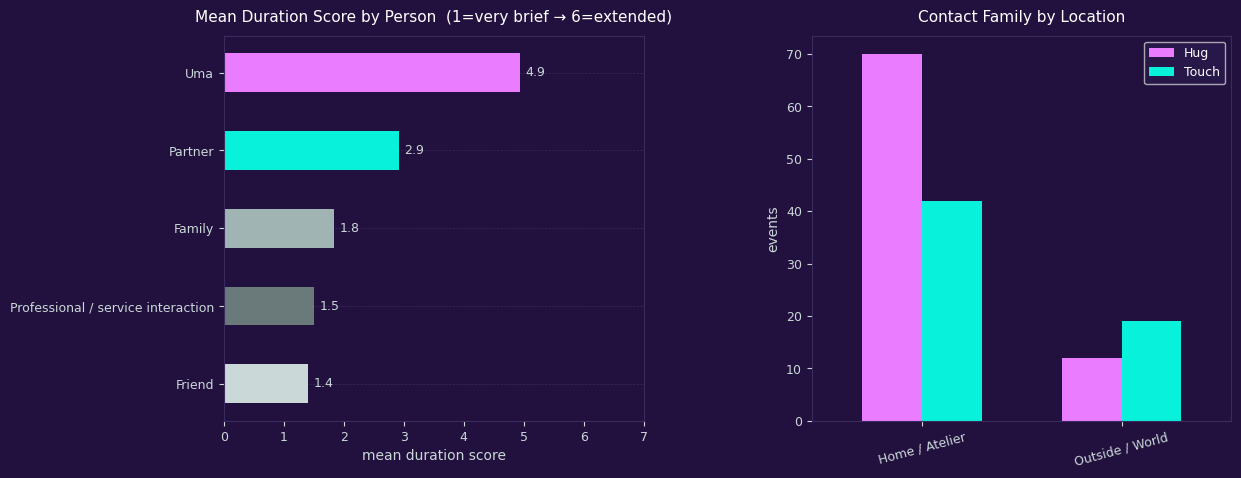

In [10]:
# ── 7b. PERSON × DURATION (mean ordinal) and LOCATION × TYPE

fig = brand_fig(figsize=(13, 5))
gs  = GridSpec(1, 2, figure=fig, wspace=0.4)

# Person × mean duration
ax1 = fig.add_subplot(gs[0])
style_ax(ax1, 'Mean Duration Score by Person  (1=very brief → 6=extended)')
mean_dur = (formA[formA['duration_ord'] > 0]
            .groupby('person')['duration_ord']
            .mean()
            .sort_values(ascending=False))
colors_d = [PERSON_COLORS.get(p, GRAY_GREEN) for p in mean_dur.index]
bars = ax1.barh(mean_dur.index, mean_dur.values, color=colors_d, height=0.5)
ax1.bar_label(bars, fmt='%.1f', color=GRAY_GREEN, fontsize=9, padding=4)
ax1.set_xlim(0, 7)
ax1.invert_yaxis()
ax1.set_xlabel('mean duration score')

# Location × contact family
ax2 = fig.add_subplot(gs[1])
style_ax(ax2, 'Contact Family by Location')
loc_ct = pd.crosstab(formA['location'], formA['contact_family'])
loc_ct.plot(kind='bar', ax=ax2,
            color=[PINK, TURQUOISE, GRAY_GREEN, '#6a5a8e'],
            width=0.6, rot=15)
ax2.legend(facecolor='#2a1a4e', labelcolor=WHITE, fontsize=9)
ax2.set_xlabel('')
ax2.set_ylabel('events')
ax2.tick_params(colors=GRAY_GREEN)

plt.tight_layout()
plt.savefig('eda_06_crosstabs.png', dpi=150, bbox_inches='tight', facecolor=DEEP_PURPLE)
plt.show()


### Observations — Cross-tabulations

The mean duration score by person (scaled 1–6 from very brief to extended) produces a near-
perfect social proximity gradient: Uma scores 4.9, Partner 2.9, Family 1.8, Professional 1.5,
Friend 1.4. The closer the relationship, the longer the touch. This is consistent with the
literature on social touch and proxemics — but it is striking to see it emerge so cleanly from
a 13-day personal log.

The contact family by location chart confirms a structural difference between domestic and
outdoor touch. At Home / Atelier, Hug-type events (70) outnumber Touch-type events (42).
Outside / World, the ratio nearly inverts: Touch (19) slightly exceeds Hug (12). Outside the
home, touch becomes briefer, less enveloping, and more gesture-like. The hug as sustained
bodily event is almost exclusively a domestic occurrence.

## 7 · Form A vs Inferred Events

Form A (real-time):  143 events
Inferred (Form B):   49 events
Total:               192 events
Inferred share:      26%

Person distribution — Form A vs Inferred:
                                    Form A  Inferred
person                                              
Family                                 4.2      32.7
Friend                                 7.0      61.2
Partner                               41.3       4.1
Professional / service interaction     1.4       0.0
Uma                                   46.2       2.0


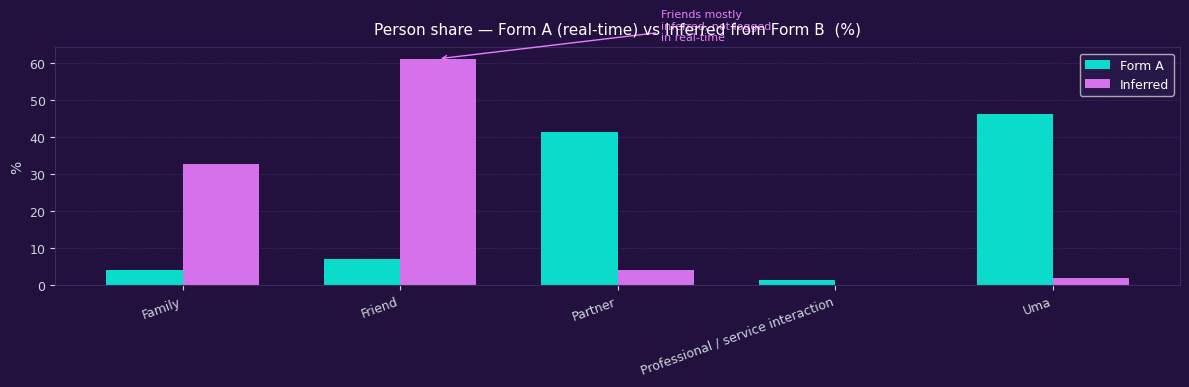

In [11]:
# ── 8. FORM A vs INFERRED COMPARISON

print(f"Form A (real-time):  {len(formA)} events")
print(f"Inferred (Form B):   {len(inferred)} events")
print(f"Total:               {len(df)} events")
print(f"Inferred share:      {len(inferred)/len(df)*100:.0f}%")
print()

# Who appears more in inferred?
print("Person distribution — Form A vs Inferred:")
comp = pd.DataFrame({
    'Form A':   formA['person'].value_counts(normalize=True).mul(100).round(1),
    'Inferred': inferred['person'].value_counts(normalize=True).mul(100).round(1),
}).fillna(0)
print(comp.to_string())

fig = brand_fig(figsize=(12, 4))
ax  = fig.add_subplot(111)
style_ax(ax, 'Person share — Form A (real-time) vs Inferred from Form B  (%)')

x     = np.arange(len(comp))
width = 0.35
ax.bar(x - width/2, comp['Form A'],   width, color=TURQUOISE, label='Form A', alpha=0.9)
ax.bar(x + width/2, comp['Inferred'], width, color=PINK,      label='Inferred', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('%')
ax.legend(facecolor='#2a1a4e', labelcolor=WHITE, fontsize=9)

# Annotate the key insight
friend_formA   = comp.loc['Friend', 'Form A']   if 'Friend' in comp.index else 0
friend_inferred= comp.loc['Friend', 'Inferred'] if 'Friend' in comp.index else 0
if friend_inferred > friend_formA:
    ax.annotate('Friends mostly\ninferred, not logged\nin real-time',
                xy=(list(comp.index).index('Friend') + width/2, friend_inferred),
                xytext=(list(comp.index).index('Friend') + 1.2, friend_inferred + 5),
                color=PINK, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=PINK, lw=1))

plt.tight_layout()
plt.savefig('eda_07_formA_vs_inferred.png', dpi=150, bbox_inches='tight', facecolor=DEEP_PURPLE)
plt.show()


### Observations — Form A vs Inferred Events

This chart is the most methodologically significant in the notebook. It shows not what was
touched, but what was capturable in the moment of touching.

Friend jumps from approximately 7% of Form A events to 61% of Inferred events. This is not
because fewer touch events with friends actually occurred — it is because social touch at
gatherings, greetings, and group events happens in bursts, in contexts where stopping to log
is either impractical or socially disruptive. These events were only recovered later, through
the daily reflection of Form B.

Uma and Partner show the inverse pattern: they dominate Form A (real-time) and almost disappear
from Inferred. Intimate domestic touch is logged immediately because it happens in a controlled
environment where the phone is accessible and logging is feasible.

This asymmetry is not a flaw in the dataset. It is a finding about the phenomenology of touch
logging itself: we notice and record what is already part of our routine attention. Social touch
at the threshold of events — greetings, goodbyes, collective moments — escapes real-time capture
almost entirely. It can only be reconstructed from memory, with all the confidence degradation
that reconstruction implies.

The dataset is therefore not a neutral record of touch. It is a record of touch filtered through
the conditions under which logging was possible.

## 8 · Highlights & Observations

In [12]:
# ── 9. AUTO-GENERATED HIGHLIGHTS

total_fa  = len(formA)
days_n    = formA['date'].nunique()
top_person= formA['person'].value_counts().idxmax()
top_pct   = formA['person'].value_counts(normalize=True).max() * 100
loc_home  = (formA['location'].str.contains('Home', na=False).sum() / total_fa) * 100
bimodal_pct = ((formA['duration'].str.contains('Brief', na=False) |
                formA['duration'].str.contains('Extended', na=False)).sum() / total_fa) * 100
uma_bodily = (formA[formA['person']=='Uma']['contact_type']
              .str.contains('Bodily', na=False).sum())
uma_total  = len(formA[formA['person']=='Uma'])

print("=" * 55)
print("  HIGHLIGHTS")
print("=" * 55)
print(f"  {total_fa} events over {days_n} days → {total_fa/days_n:.1f} avg/day")
print()
print(f"  {top_person} is the most-logged person ({top_pct:.0f}% of events)")
print()
print(f"  {loc_home:.0f}% of touch happens at home")
print()
print(f"  {bimodal_pct:.0f}% of events are either very brief OR extended")
print(f"  → bimodal: social touch vs sustained bodily care")
print()
print(f"  {uma_bodily}/{uma_total} events with Uma are 'Hug - Bodily care'")
print(f"  ({uma_bodily/uma_total*100:.0f}%) → touch as sustained condition, not discrete event")
print()
print(f"  Inferred events: {len(inferred)} ({len(inferred)/len(df)*100:.0f}% of total)")
print(f"  → social events outside home are systematically under-logged")
print()
print("  WHAT ESCAPES THE LOG:")
print("  · Residual touch (perfume trace on Uma's head — ITE-022)")
print("  · Observer effect (Partner performing for the dataset — ITE-023)")
print("  · Non-touch moments ('It wasn't a touch, it was a smile' — Form B, May 28)")


  HIGHLIGHTS
  143 events over 13 days → 11.0 avg/day

  Uma is the most-logged person (46% of events)

  78% of touch happens at home

  64% of events are either very brief OR extended
  → bimodal: social touch vs sustained bodily care

  45/66 events with Uma are 'Hug - Bodily care'
  (68%) → touch as sustained condition, not discrete event

  Inferred events: 49 (26% of total)
  → social events outside home are systematically under-logged

  WHAT ESCAPES THE LOG:
  · Residual touch (perfume trace on Uma's head — ITE-022)
  · Observer effect (Partner performing for the dataset — ITE-023)
  · Non-touch moments ('It wasn't a touch, it was a smile' — Form B, May 28)


## Cross-Cutting Highlights

These are the findings that only become visible when looking across all charts simultaneously —
patterns that no single distribution reveals on its own.

**1. The bimodal structure of intimate touch**  
Duration, contact type, and person all point to the same underlying structure: touch in this
dataset has two modes and almost no middle ground. There is brief social touch (quick, gestural,
standard) and there is extended bodily care (prolonged, enveloping, caregiving). The scarcity
of medium and long durations is not a gap in the data — it is a gap in lived experience. The
in-between hug, the touch that lasts 30 seconds to 2 minutes, is genuinely rare.

**2. Uma and Partner as two distinct touch languages**  
The Person × Contact Type heatmap makes this structural separation impossible to ignore. Uma
and Partner share almost no contact type, no duration range, and no dominant intention. They
are the two most-present people in the dataset and they inhabit entirely different registers
of touch. Uma is care, duration, bodily presence. Partner is affection, play, brevity. The
same person — the logger — operates in two different somatic vocabularies depending on who
they are touching, sometimes within the same hour.

**3. The nocturnal care signal**  
The circadian chart reveals something most self-tracking datasets erase entirely: there are
logged touch events at every hour between midnight and 6am. These are not outliers. They are
a consistent 2-events-per-hour baseline that points to nighttime caregiving as a structural
feature of this person's daily touch ecology. A dataset of touch that ignored these hours
would miss one of its most distinctive features.

**4. Social touch is systematically invisible to real-time logging**  
The Form A vs Inferred comparison shows that Friend touch jumps from 7% to 61% when moving
from real-time to reconstructed data. This is not unique to this dataset — it is a structural
property of any self-logging method applied to social contexts. Touch that happens in greeting
clusters, group departures, and social gatherings cannot be logged as it happens. It lives in
memory, not in timestamps. Any future dataset or installation that attempts to capture social
touch in real time will face this same asymmetry.

**5. The proximity gradient holds — and is measurable**  
Mean duration by person produces a near-perfect social closeness ranking: Uma (4.9) → Partner
(2.9) → Family (1.8) → Professional (1.5) → Friend (1.4). What the literature on affective
touch describes theoretically — that duration scales with relational intimacy — appears cleanly
in 13 days of personal data. This suggests that even a small, informal, self-reported log can
reproduce findings from controlled laboratory studies, while adding layers of context and
ambiguity that lab settings cannot produce.

---

## Methodological Observations

What the process of logging revealed beyond the data itself.

**The log changes what it measures**  
From the moment the dataset became visible to others, it began producing its own effects.
Partner discovered the log and started performing for it — announcing durations, exaggerating
gestures, testing the boundaries of the categories. ITE-023 was logged with confidence: low.
This is not a contamination problem to be solved; it is a finding about the social life of
datasets. A dataset of intimate touch, once shared with its subjects, becomes part of the
touch ecology it is trying to document.

**Real-time logging is a domestic privilege**  
The Form A / Inferred asymmetry reveals that real-time logging requires a specific set of
conditions: a phone nearby, a moment of pause, a social context that tolerates the interruption.
These conditions are reliably present at home and reliably absent in social gatherings. This
means the dataset is not a random sample of touch events — it is a sample of touch events that
occurred in logistically favorable conditions. Any claim about frequency must account for this
structural bias.

**Some events have no field**  
Form B, May 28: *"It wasn't a touch, it was a smile."* The most memorable moment of an entire
day had no entry in Form A because it did not qualify as touch under the form's definitions.
The form had no field for proximity without contact, for presence without pressure, for the
look that carries the same weight as an arm around a shoulder. The boundary of the dataset is
also a statement about what counts as touch — and that statement is always partial.

**Residual touch exists and is classifiable — barely**  
ITE-022 documents the perfume of Uma's grandfather remaining on her head after he held her.
The event was inferred, logged with high confidence, and assigned a person — but it is not
really that person's touch. It is a trace, a residue, a third-order contact. The dataset
accommodated it, but only by bending its own categories. This edge case points directly at
the central question of the Hugging Face project: if even a careful human logger struggles
to classify residual touch, what does a machine do with it?